In [1]:
# ---------- 1. packages----------
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import os
plt.rcParams['font.sans-serif'] = ['SimHei', 'PingFang SC', 'Noto Sans CJK JP']
plt.rcParams['axes.unicode_minus'] = False
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report, roc_curve
import warnings
warnings.filterwarnings('ignore')

In [2]:
a = pd.read_csv("online_retail_cleaned.csv")

In [3]:
df = pd.read_csv("online_retail_cleaned.csv")
df = pd.DataFrame({"Description": df["Description"].unique()})

In [4]:
# ---------- 2. ext Embedding ----------
vectorizer = TfidfVectorizer(
    max_features=500,        
    stop_words='english',    
    ngram_range=(1, 2)       
)
tfidf_matrix = vectorizer.fit_transform(df['Description'])

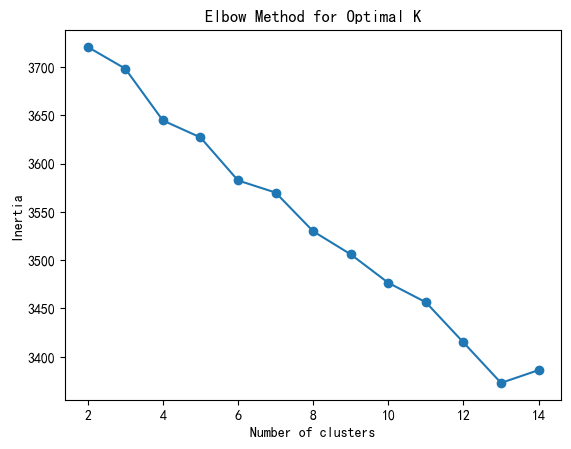

In [5]:
# ---------- 3. Determine the Number of Clusters ----------
# Method: Elbow Method — Plotting the cost function against different K values
inertia = []
for k in range(2, 15):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix)
    inertia.append(km.inertia_)

plt.plot(range(2, 15), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [6]:
optimal_k = 13   
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(tfidf_matrix)

In [7]:
# ---------- 5. 查看每个类别的代表性商品 ----------
def get_top_terms_per_cluster(vectorizer, kmeans, n_terms=5):
    """返回每个类别最重要的 n 个词"""
    terms = vectorizer.get_feature_names_out()
    order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
    top_terms = {}
    for i in range(kmeans.n_clusters):
        top_terms[i] = [terms[ind] for ind in order_centroids[i, :n_terms]]
    return top_terms

top_terms = get_top_terms_per_cluster(vectorizer, kmeans)
print("Keywords per Category：")
for cluster_id, words in top_terms.items():
    print(f"Cluster {cluster_id}: {words}")

print("\nexamples：")
for cluster_id in sorted(df['cluster'].unique()):
    samples = df[df['cluster'] == cluster_id]['Description'].head(5).tolist()
    print(f"\n--- Cluster {cluster_id} ---")
    for s in samples:
        print(f"  • {s}")

df.to_csv('classified_products.csv', index=False)
print("\nsave at classified_products.csv")

Keywords per Category：
Cluster 0: ['light', 'holder', 'light holder', 'glass', 'hanging']
Cluster 1: ['bag', 'jumbo', 'jumbo bag', 'bag vintage', 'vintage']
Cluster 2: ['red', 'retrospot', 'red retrospot', 'gingham', 'small']
Cluster 3: ['cover', 'cushion', 'cushion cover', 'food cover', 'food']
Cluster 4: ['set', 'lights', 'paper', 'tins', 'set 12']
Cluster 5: ['christmas', 'tree', 'christmas tree', 'decoration', 'star']
Cluster 6: ['art', 'wall', 'wall art', 'mirrored wall', 'mirrored']
Cluster 7: ['pink', 'heart', 'decoration', 'white', 'small']
Cluster 8: ['glass', 'black', 'white', 'candle', 'box']
Cluster 9: ['vintage', 'vintage christmas', 'christmas', 'vintage red', 'set']
Cluster 10: ['blue', 'blue polkadot', 'polkadot', 'flower', 'ceramic']
Cluster 11: ['metal', 'sign', 'metal sign', 'blue metal', 'french']
Cluster 12: ['design', 'mug', 'box', 'pantry', 'coffee mug']

examples：

--- Cluster 0 ---
  • WHITE HANGING HEART T-LIGHT HOLDER
  • GLASS STAR FROSTED T-LIGHT HOLDER
  •

In [8]:
classified_df = pd.read_csv("classified_products.csv")

In [9]:
merged = a.merge(
    classified_df[['Description', 'cluster']],
    left_on='Description',
    right_on='Description',
    how='inner'
)

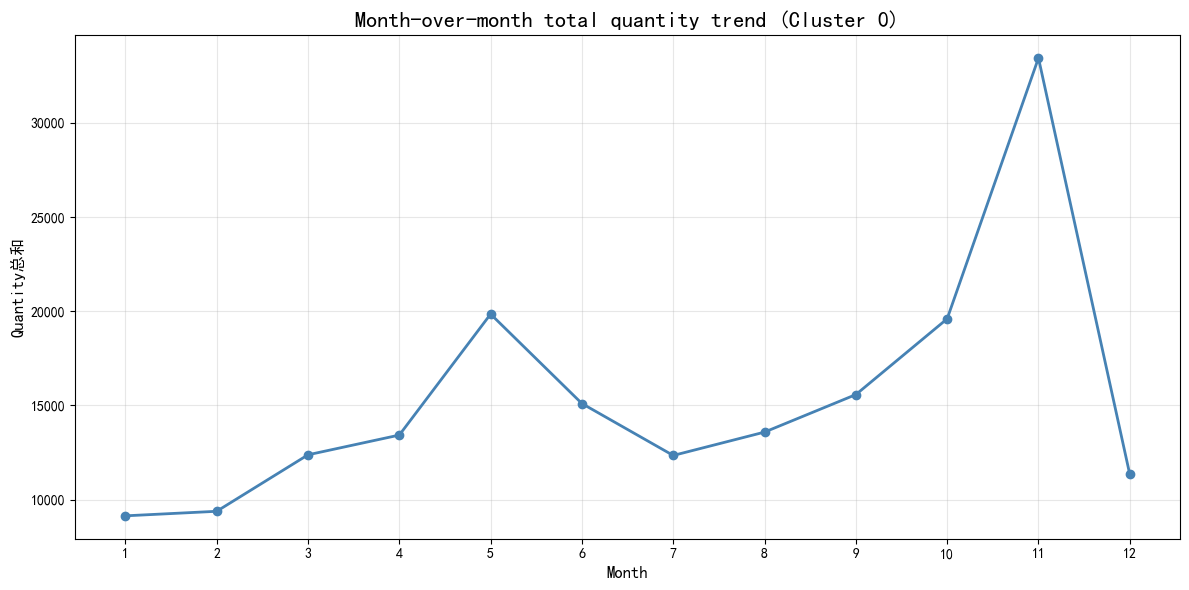

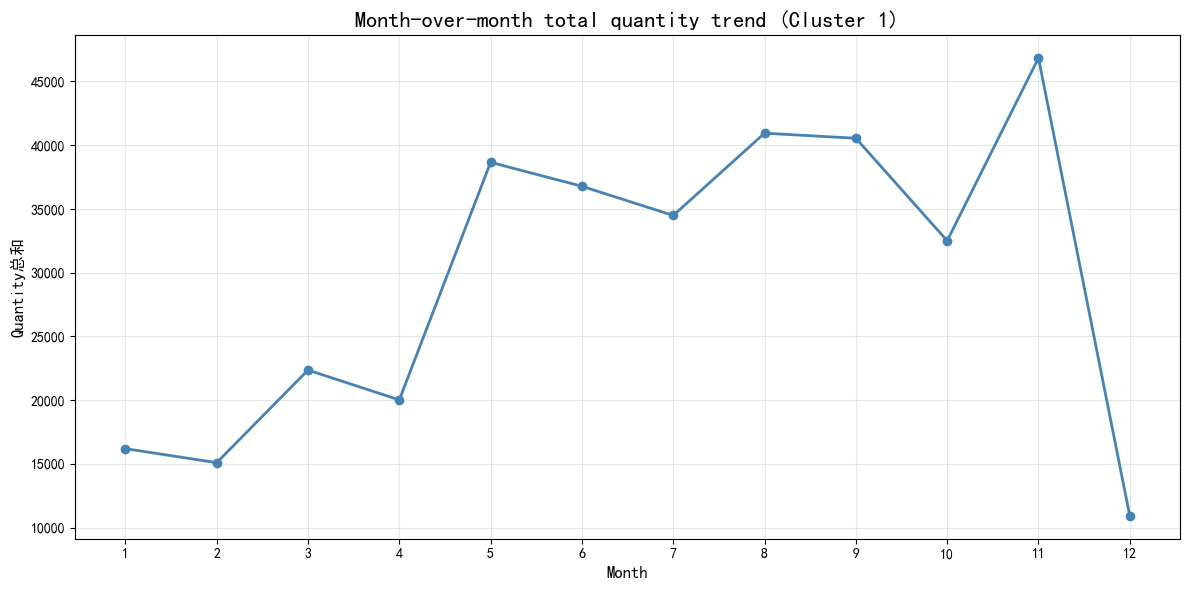

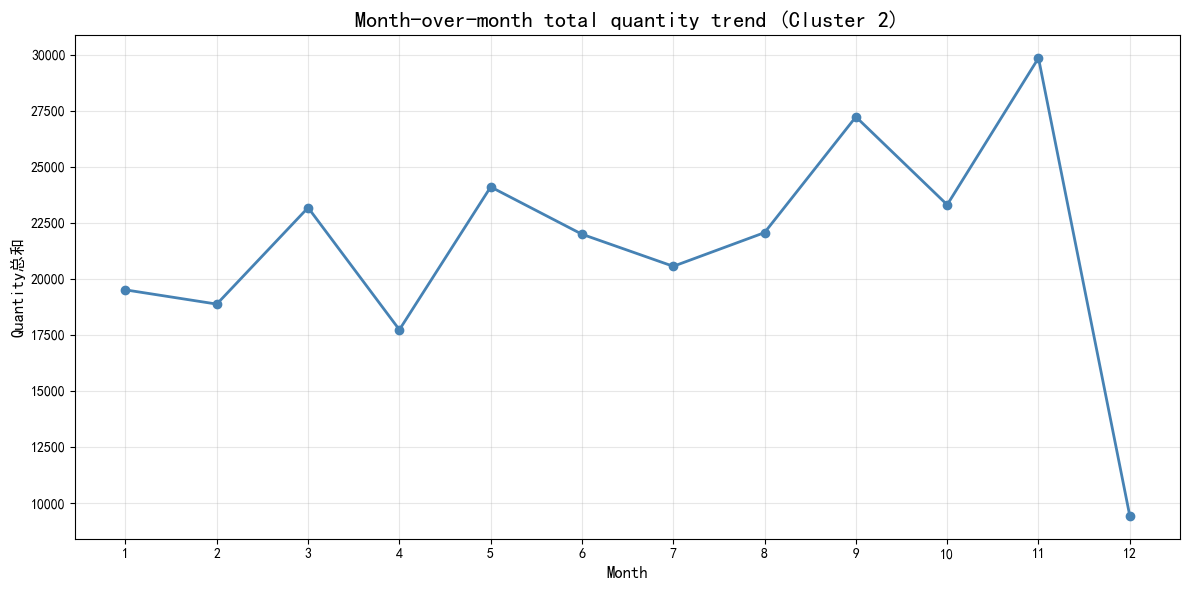

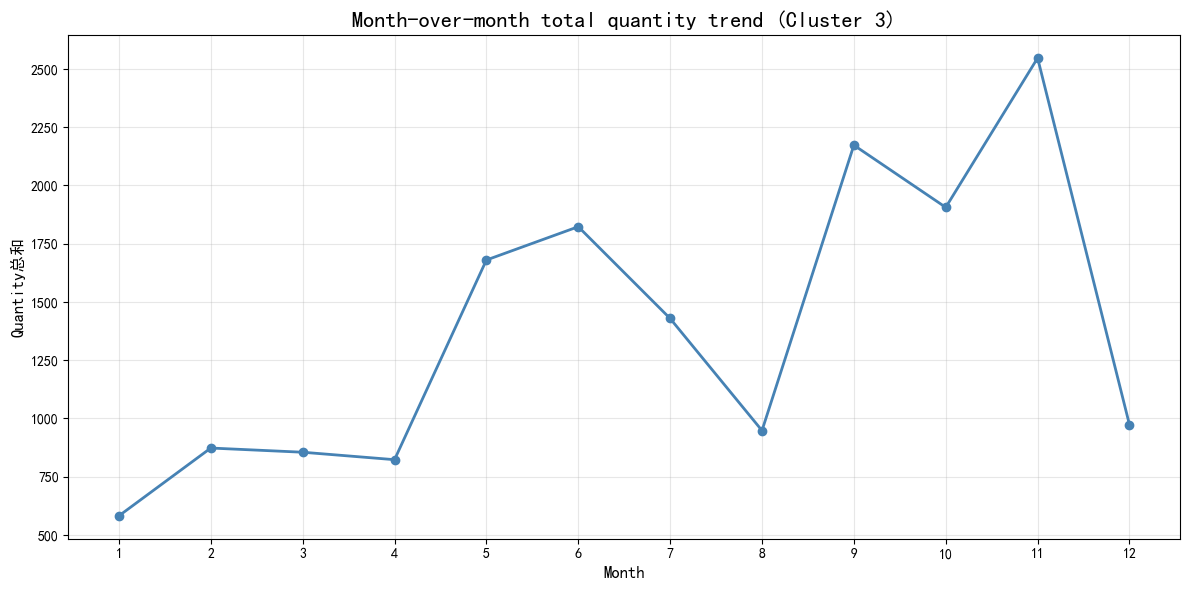

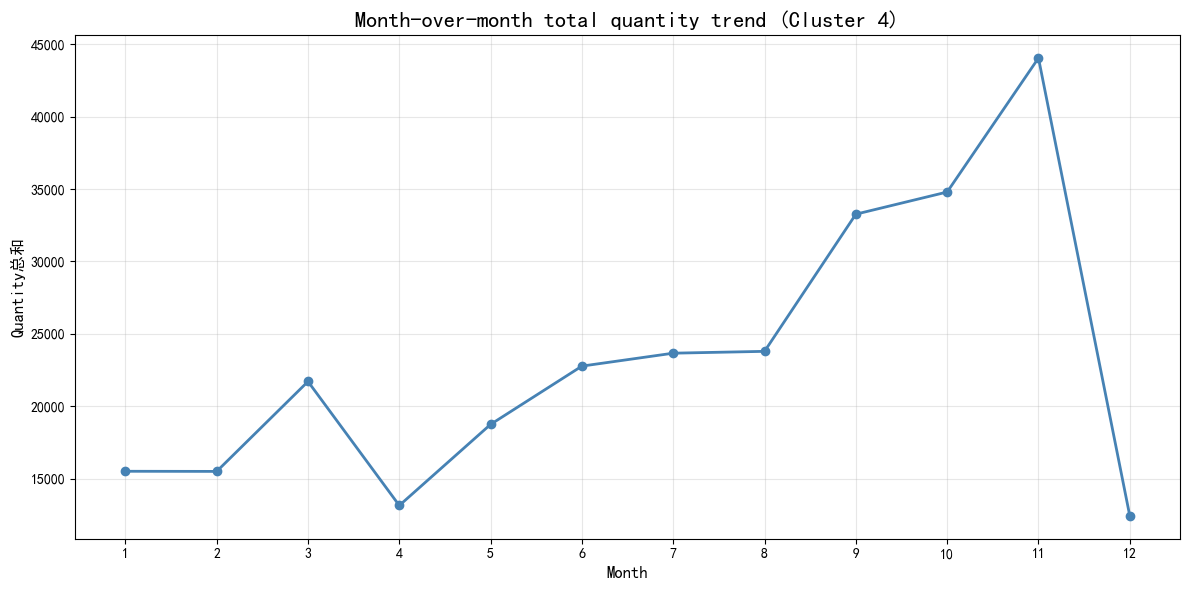

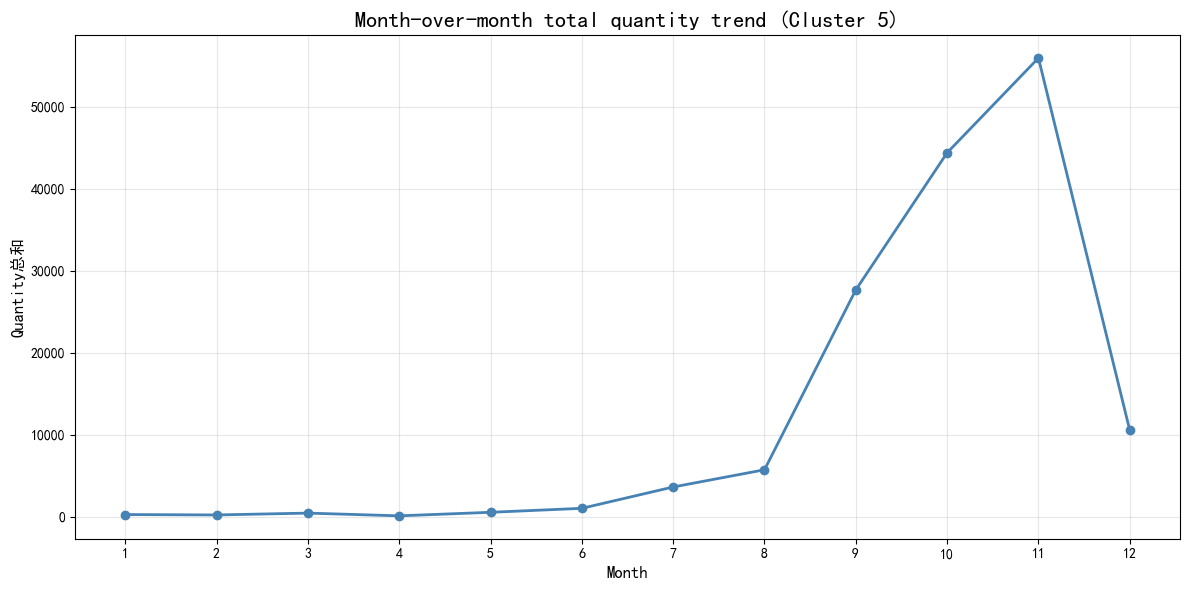

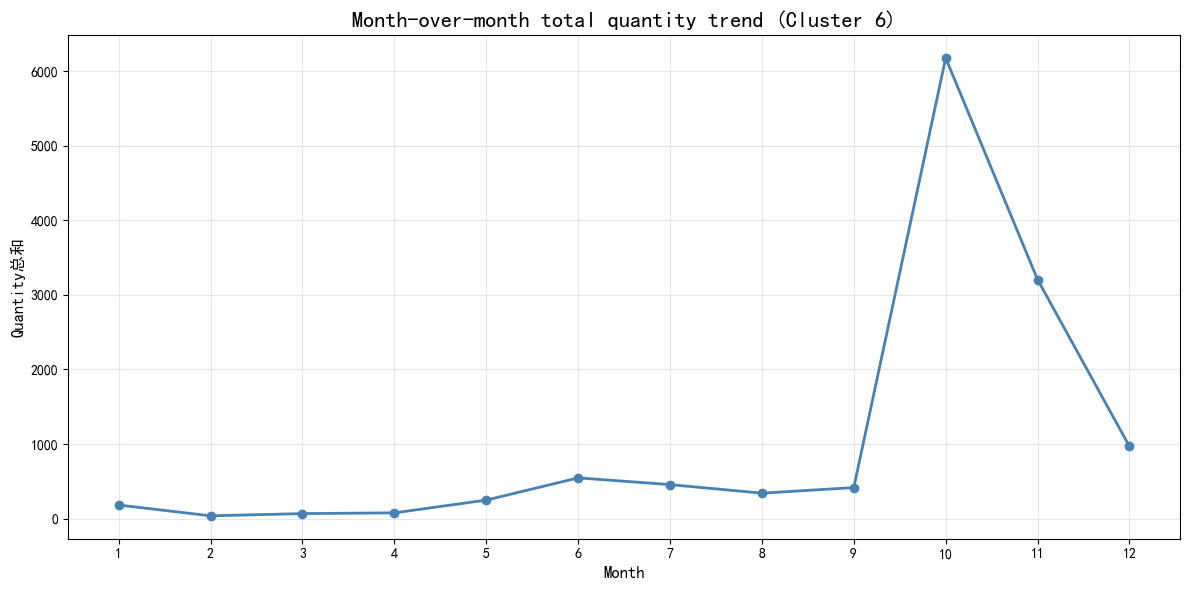

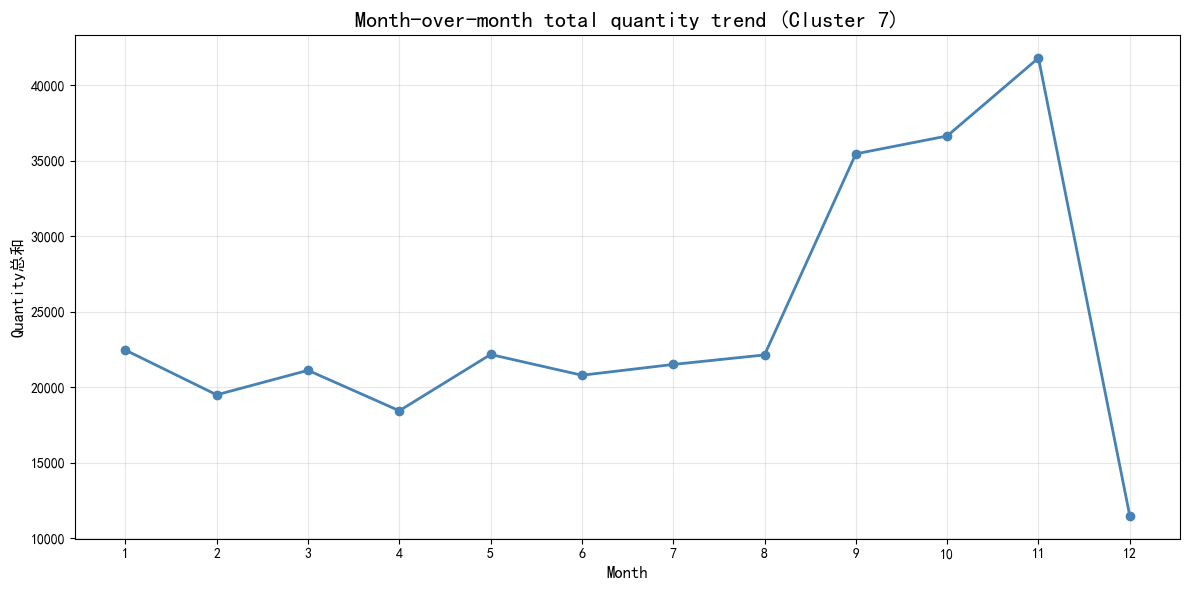

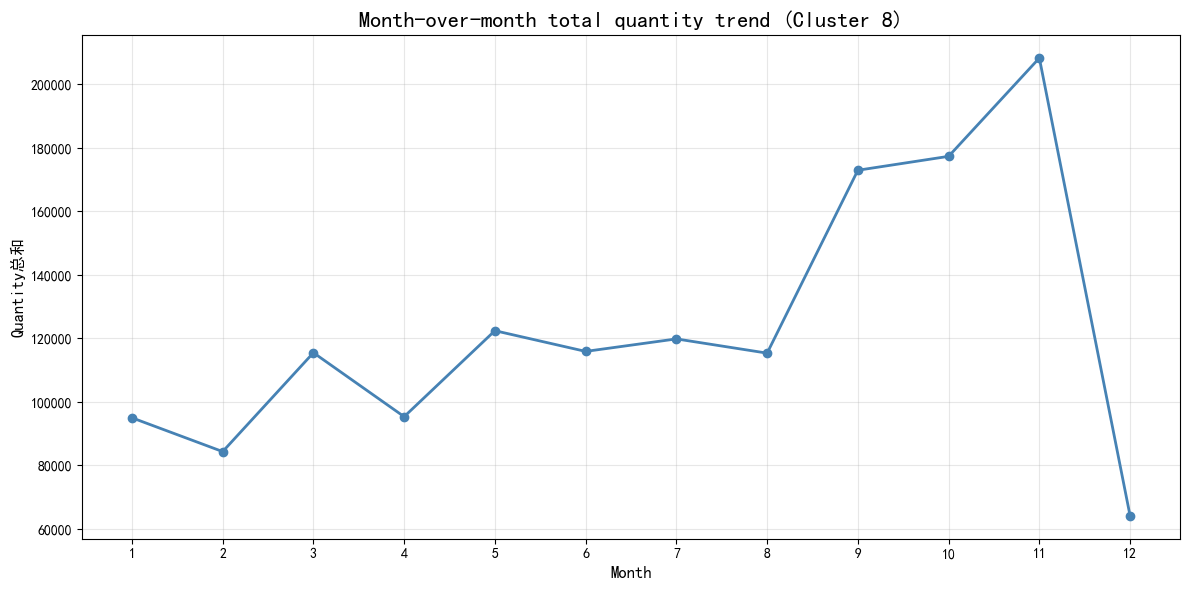

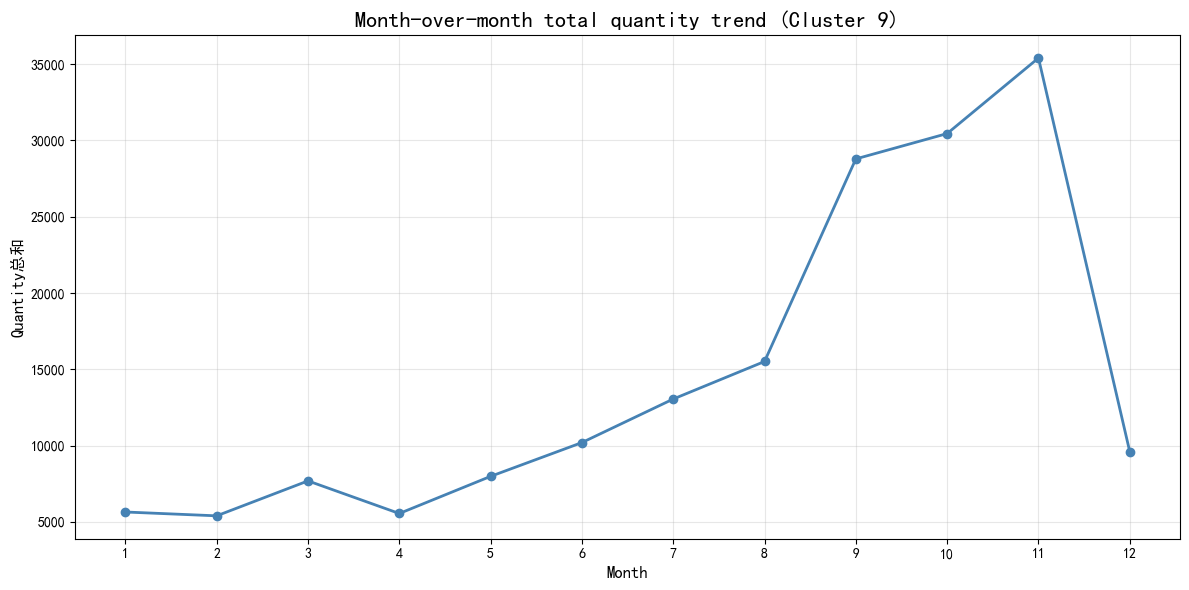

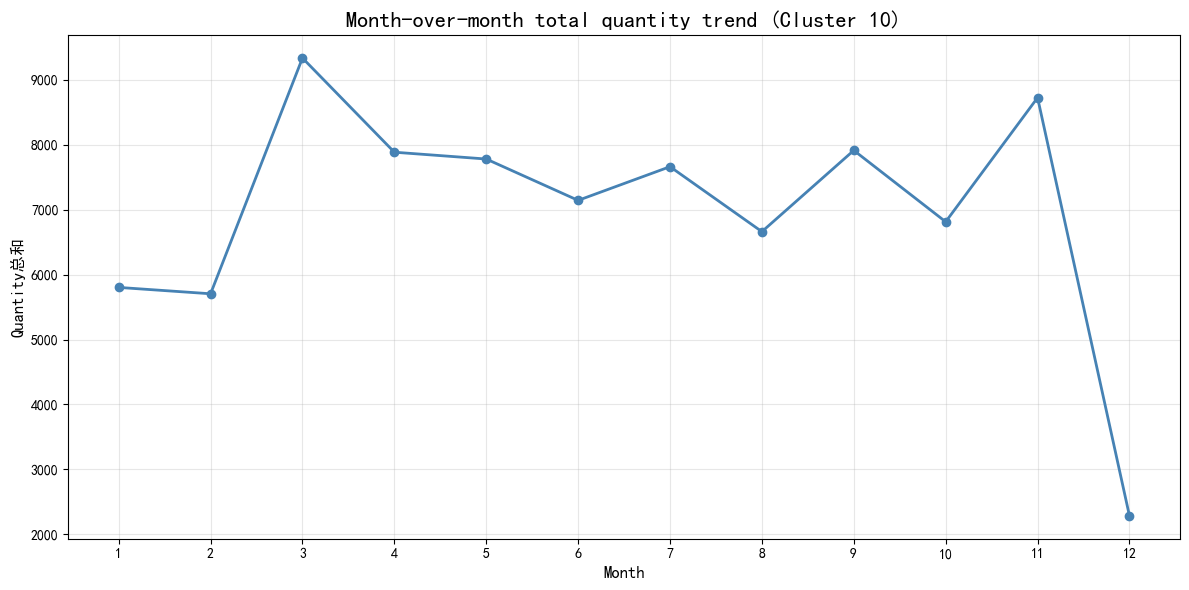

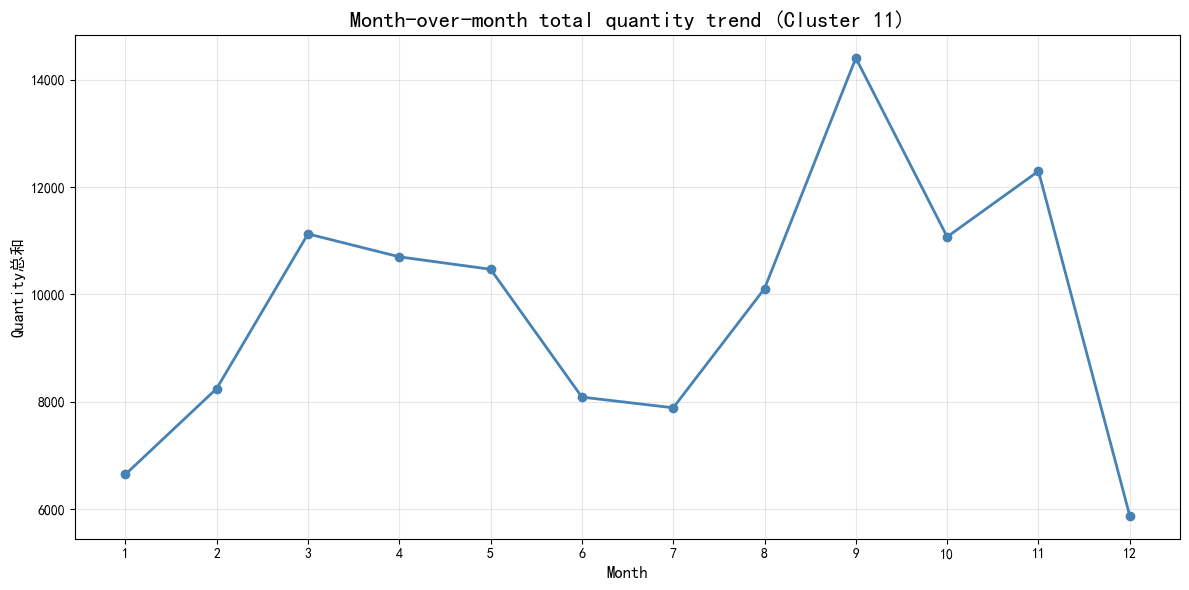

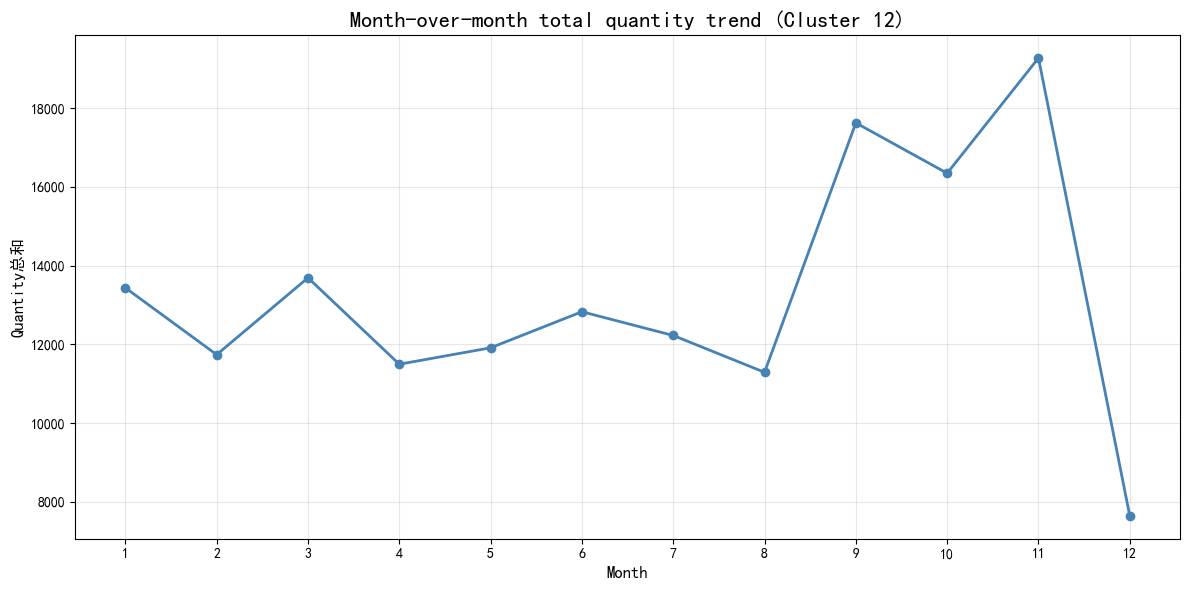

In [10]:
for i in range(13):
    
    monthly_qty = monthly_qty = merged[(merged['cluster'] == i) & (merged['Year'] == 2011)].groupby('Month')['Quantity'].sum()

    plt.figure(figsize=(12, 6))
    plt.plot(monthly_qty.index, monthly_qty.values, marker='o', linewidth=2, color='steelblue')
    plt.title(f'Month-over-month total quantity trend (Cluster {i})', fontsize=16)
    plt.xlabel('Month', fontsize=12)
    plt.ylabel('Quantity总和', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.savefig(f'monthly_quantity_cluster{i}.png', dpi=300)
    plt.show()

Original data shape: (397594, 18)
Time range: 2010-12-01 08:26:00 ~ 2011-12-09 12:50:00
Number of customers: 4337
Data span: 373 days
Training transactions: 325022, Validation transactions: 63801
Training period end date: 2011-11-09
Number of training customers: 4039, Repurchase rate: 33.92%
Train set size: (3231, 14), Validation set size: (808, 14)

Logistic Regression Performance:
  ROC-AUC : 0.7535
  F1-Score: 0.5874
  Accuracy: 0.7252
                precision    recall  f1-score   support

Not Repurchase       0.79      0.80      0.79       534
    Repurchase       0.60      0.58      0.59       274

      accuracy                           0.73       808
     macro avg       0.69      0.69      0.69       808
  weighted avg       0.72      0.73      0.72       808


Random Forest Performance:
  ROC-AUC : 0.7409
  F1-Score: 0.5784
  Accuracy: 0.7240
                precision    recall  f1-score   support

Not Repurchase       0.78      0.81      0.79       534
    Repurchase      

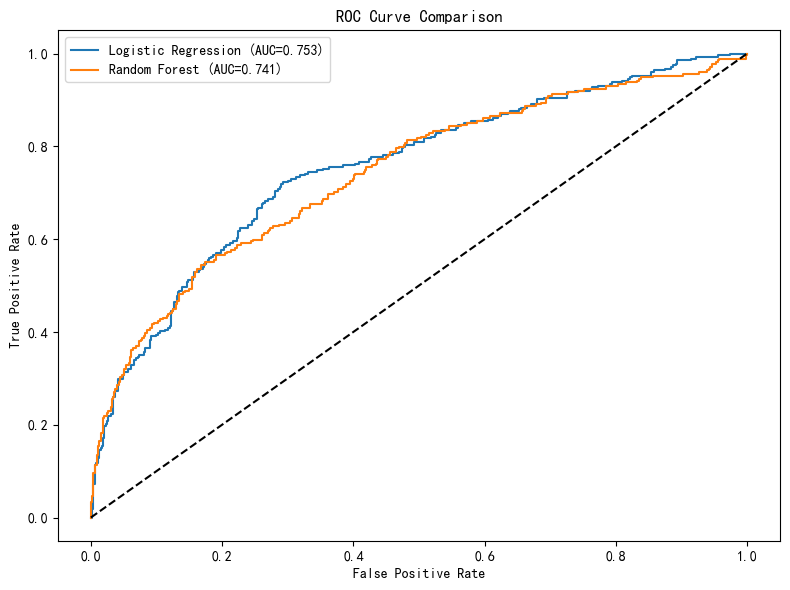

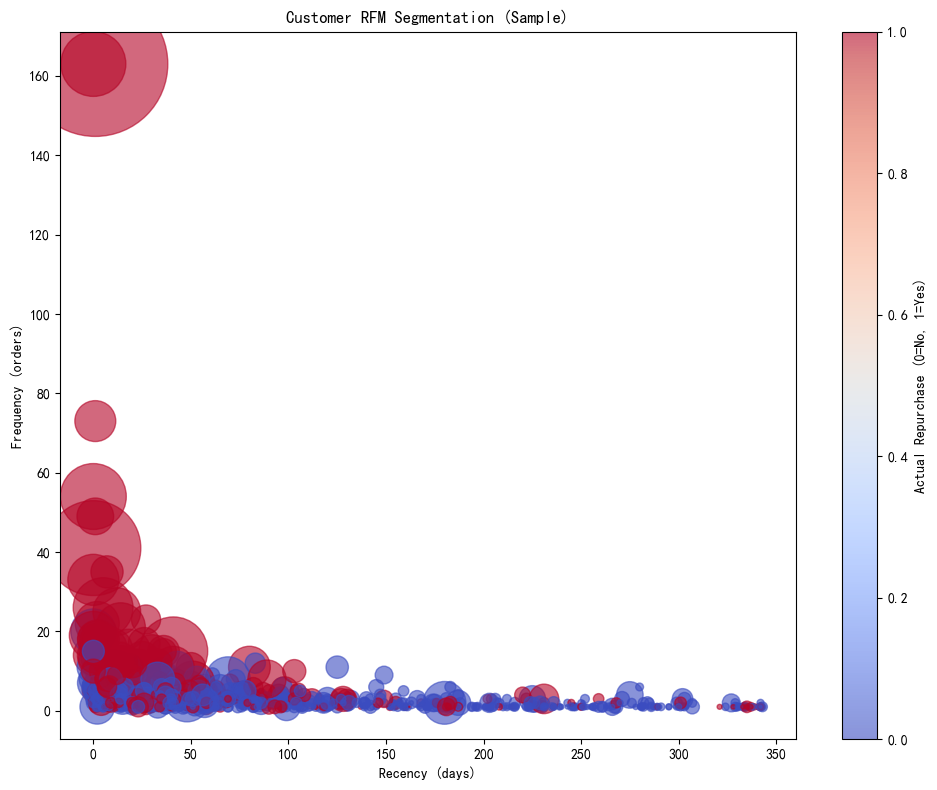

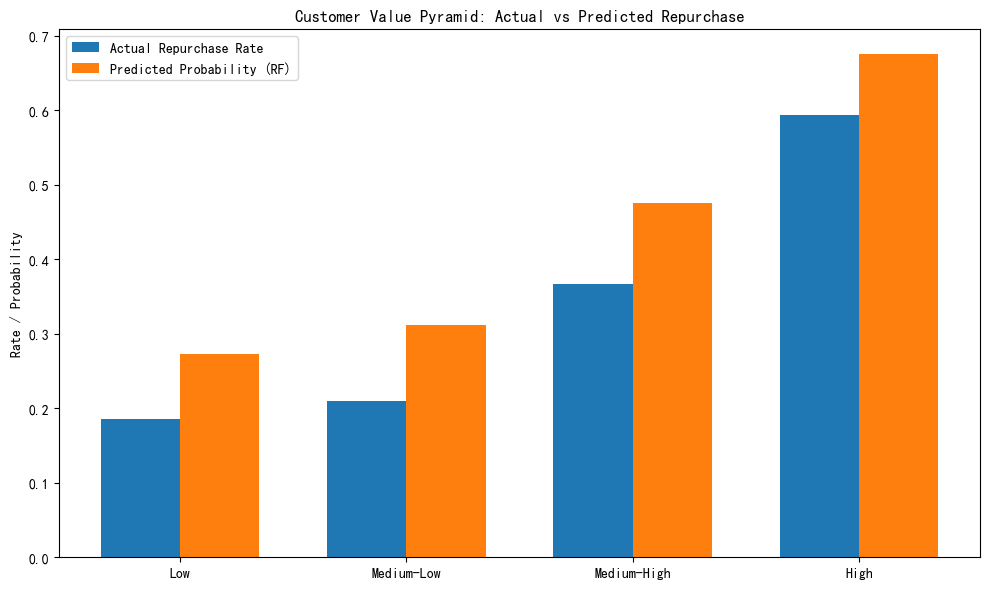

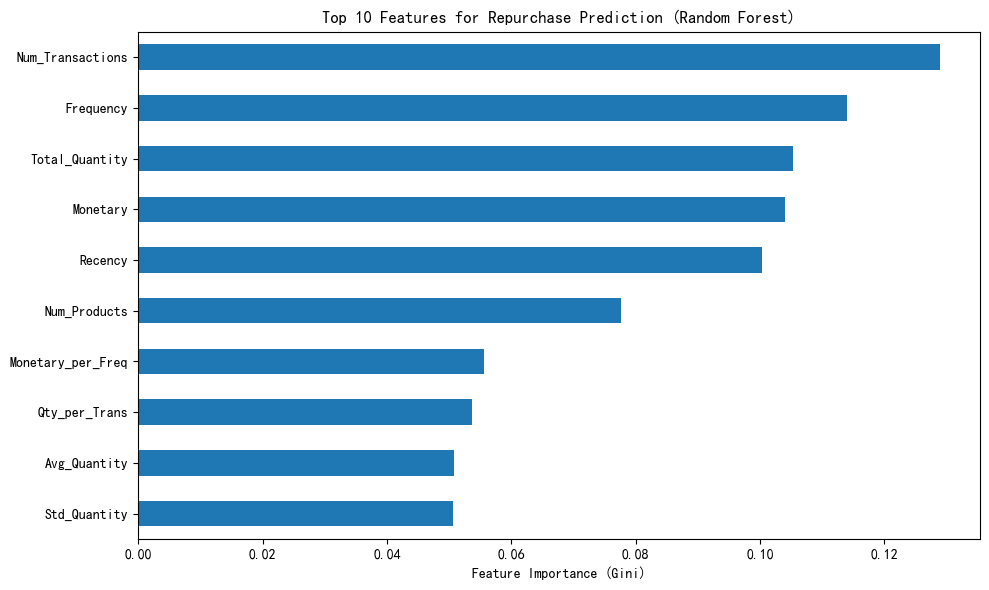

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report, roc_curve
import warnings
warnings.filterwarnings('ignore')

# ==================== 1. Data Loading ====================
df = pd.read_csv('merged_products.csv', parse_dates=['InvoiceDate'])
print(f"Original data shape: {df.shape}")
print(f"Time range: {df['InvoiceDate'].min()} ~ {df['InvoiceDate'].max()}")
print(f"Number of customers: {df['CustomerID'].nunique()}")

# ==================== 2. Data Preprocessing ====================
df_sale = df[df['IsReturn'] == False].copy()
df_sale = df_sale[(df_sale['Quantity'] > 0) & (df_sale['UnitPrice'] > 0)]

df_sale.sort_values(['CustomerID', 'InvoiceDate'], inplace=True)

# ==================== 3. Time Series Split ====================
# Determine total days in data (assumed approx. 365 days)
total_days = (df_sale['InvoiceDate'].max() - df_sale['InvoiceDate'].min()).days
print(f"Data span: {total_days} days")

# Set training period: first 11 months (approx. 335 days), validation period: last 30 days
train_end_date = df_sale['InvoiceDate'].max() - timedelta(days=30)
train_df = df_sale[df_sale['InvoiceDate'] <= train_end_date].copy()
val_df = df_sale[df_sale['InvoiceDate'] > train_end_date].copy()

print(f"Training transactions: {len(train_df)}, Validation transactions: {len(val_df)}")
print(f"Training period end date: {train_end_date.date()}")

# ==================== 4. Feature Engineering (Customer Level) ====================
def build_customer_features(transactions, label_flag=False, label_start_date=None):
    """
    Aggregate customer-level features from transaction data.
    label_flag: Whether to generate repurchase labels (checks if customer transacted after label_start_date).
    """
    # Use the latest date in the training period as reference for Recency calculation
    if label_flag:
        ref_date = label_start_date  # End date of training period
    else:
        ref_date = transactions['InvoiceDate'].max() + timedelta(days=1)

    # Basic RFM features
    rfm = transactions.groupby('CustomerID').agg(
        Recency=('InvoiceDate', lambda x: (ref_date - x.max()).days),
        Frequency=('InvoiceNo', 'nunique'),
        Monetary=('TotalAmount', 'sum')
    ).reset_index()

    # Additional features
    extra = transactions.groupby('CustomerID').agg(
        Avg_OrderValue=('TotalAmount', 'mean'),
        Max_OrderValue=('TotalAmount', 'max'),
        Min_OrderValue=('TotalAmount', 'min'),
        Num_Products=('StockCode', 'nunique'),
        Num_Transactions=('InvoiceNo', 'nunique'),
        Total_Quantity=('Quantity', 'sum'),
        Avg_Quantity=('Quantity', 'mean'),
        Std_Quantity=('Quantity', 'std'),
        Cluster=('cluster', 'first')  # Directly take cluster label
    ).reset_index()

    # Merge features
    features = rfm.merge(extra, on='CustomerID', how='left')

    # Derived features
    features['Monetary_per_Freq'] = features['Monetary'] / (features['Frequency'] + 1e-5)
    features['Qty_per_Trans'] = features['Total_Quantity'] / (features['Num_Transactions'] + 1e-5)
    features['Std_Quantity'].fillna(0, inplace=True)

    # Generate label: whether the customer had a transaction after label_start_date
    if label_flag:
        future_trans = df_sale[df_sale['InvoiceDate'] >= label_start_date]
        repurchased = set(future_trans['CustomerID'].unique())
        features['Repurchase'] = features['CustomerID'].isin(repurchased).astype(int)

    return features

# Training set features (using training period transactions, labels from validation period)
train_features = build_customer_features(train_df, label_flag=True, label_start_date=train_end_date)
print(f"Number of training customers: {train_features.shape[0]}, Repurchase rate: {train_features['Repurchase'].mean():.2%}")

train_df_sorted = train_df.sort_values('InvoiceDate')
split_point = int(len(train_df_sorted) * 0.8)
inner_train_df = train_df_sorted.iloc[:split_point]
inner_val_df = train_df_sorted.iloc[split_point:]

inner_train_features = build_customer_features(inner_train_df, label_flag=True, 
                                               label_start_date=inner_val_df['InvoiceDate'].min())
# Note: Labels are generated using transactions in inner_val_df, so 'Repurchase' indicates repurchase during the inner_val period.
X_inner_train = inner_train_features.drop(['CustomerID', 'Repurchase'], axis=1)
y_inner_train = inner_train_features['Repurchase']

X = train_features.drop(['CustomerID', 'Repurchase'], axis=1)
y = train_features['Repurchase']

from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set size: {X_train.shape}, Validation set size: {X_val.shape}")

# ==================== 5. Scaling ====================
scaler = StandardScaler()
numeric_cols = ['Recency', 'Frequency', 'Monetary', 'Avg_OrderValue', 'Max_OrderValue',
                'Min_OrderValue', 'Num_Products', 'Num_Transactions', 'Total_Quantity',
                'Avg_Quantity', 'Std_Quantity', 'Monetary_per_Freq', 'Qty_per_Trans']
# Cluster is a categorical numeric label, not scaled
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val_scaled[numeric_cols] = scaler.transform(X_val[numeric_cols])

# ==================== 6. Model Training ====================
# Model 1: Logistic Regression (with L2 regularization, balanced classes)
lr = LogisticRegression(C=1.0, penalty='l2', solver='liblinear', class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_val_scaled)
y_prob_lr = lr.predict_proba(X_val_scaled)[:, 1]

# Model 2: Random Forest (balanced classes)
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=10,
                            class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # Random Forest does not require scaling
y_pred_rf = rf.predict(X_val)
y_prob_rf = rf.predict_proba(X_val)[:, 1]

# ==================== 7. Evaluation ====================
def evaluate_model(y_true, y_pred, y_prob, model_name):
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{model_name} Performance:")
    print(f"  ROC-AUC : {auc:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=['Not Repurchase', 'Repurchase']))
    return auc, f1, acc

auc_lr, f1_lr, acc_lr = evaluate_model(y_val, y_pred_lr, y_prob_lr, "Logistic Regression")
auc_rf, f1_rf, acc_rf = evaluate_model(y_val, y_pred_rf, y_prob_rf, "Random Forest")

# Comparison Table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [auc_lr, auc_rf],
    'F1-Score': [f1_lr, f1_rf],
    'Accuracy': [acc_lr, acc_rf]
})
print("\n===== Model Performance Comparison =====")
print(results.to_string(index=False))

# ==================== 8. Visualization ====================
# Visualization 1: ROC Curve
plt.figure(figsize=(8,6))
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_prob_rf)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png')
plt.show()

# Visualization 2: RFM Scatter Plot (Sample of 1000 customers)
sample = train_features.sample(1000, random_state=42)
plt.figure(figsize=(10,8))
scatter = plt.scatter(sample['Recency'], sample['Frequency'], 
                      c=sample['Repurchase'], cmap='coolwarm', alpha=0.6,
                      s=sample['Monetary']/10)
plt.colorbar(scatter, label='Actual Repurchase (0=No, 1=Yes)')
plt.xlabel('Recency (days)')
plt.ylabel('Frequency (orders)')
plt.title('Customer RFM Segmentation (Sample)')
plt.tight_layout()
plt.savefig('rfm_scatter.png')
plt.show()

# Visualization 3: Customer Value Pyramid (Quartile segmentation by Monetary)
train_features['Value_Tier'] = pd.qcut(train_features['Monetary'], q=4, 
                                       labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
tier_stats = train_features.groupby('Value_Tier').agg(
    Customer_Count=('CustomerID', 'count'),
    Actual_Repurchase_Rate=('Repurchase', 'mean')
).reset_index()
# Model prediction probability (using RF predictions on training set)
tier_stats['Predicted_Prob'] = train_features.groupby('Value_Tier')['Repurchase'].apply(
    lambda x: rf.predict_proba(X.loc[x.index])[:,1].mean()
).values

fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(tier_stats))
width = 0.35
ax.bar(x - width/2, tier_stats['Actual_Repurchase_Rate'], width, label='Actual Repurchase Rate')
ax.bar(x + width/2, tier_stats['Predicted_Prob'], width, label='Predicted Probability (RF)')
ax.set_xticks(x)
ax.set_xticklabels(tier_stats['Value_Tier'])
ax.set_ylabel('Rate / Probability')
ax.set_title('Customer Value Pyramid: Actual vs Predicted Repurchase')
ax.legend()
plt.tight_layout()
plt.savefig('value_pyramid.png')
plt.show()

# Visualization 4: Feature Importance (Random Forest Top 10)
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
feat_imp.plot(kind='barh')
plt.xlabel('Feature Importance (Gini)')
plt.title('Top 10 Features for Repurchase Prediction (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()